In [1]:
print("Ramya R")
print("24BAD096")

import tensorflow as tf
import numpy as np
import re
import string

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set vocabulary size and maximum review length
vocab_size = 10000
max_length = 200

# Load IMDB dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))

# Check sentiment distribution
print("\nTraining Positive Reviews:", np.sum(y_train == 1))
print("Training Negative Reviews:", np.sum(y_train == 0))

# Display sample reviews as numerical sequences
print("\nSample Review:")
print(x_train[0])

# Padding sequences
x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')

print("\nShape of training data:", x_train.shape)
print("Shape of testing data:", x_test.shape)

# Labels are already encoded as 0 and 1
y_train = np.array(y_train)
y_test = np.array(y_test)

print("\nSample label:", y_train[0])

# Split training data into training and validation
x_val = x_train[:5000]
y_val = y_train[:5000]

x_train_new = x_train[5000:]
y_train_new = y_train[5000:]

print("\nFinal Training Shape:", x_train_new.shape)
print("Validation Shape:", x_val.shape)
print("Testing Shape:", x_test.shape)

Ramya R
24BAD096
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training samples: 25000
Number of testing samples: 25000

Training Positive Reviews: 12500
Training Negative Reviews: 12500

Sample Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 

In [2]:
print("Ramya R")
print("24BAD096")

import tensorflow as tf
from tensorflow.keras.layers import Embedding

# Vocabulary size and embedding dimension
vocab_size = 10000
embedding_dim = 64

# Create Embedding layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)

# Generate embeddings for training sequences
embedding_output = embedding_layer(x_train_new)

# Display shapes
print("Input sequence shape:", x_train_new.shape)
print("Embedding output shape:", embedding_output.shape)

# Display embedding of first review
print("\nEmbedding of first review:")
print(embedding_output[0])

# Display embedding vector of first word
print("\nEmbedding vector of first word:")
print(embedding_output[0][0])

Ramya R
24BAD096
Input sequence shape: (20000, 200)
Embedding output shape: (20000, 200, 64)

Embedding of first review:
tf.Tensor(
[[-0.00905057  0.00675797 -0.03195732 ... -0.02094221 -0.02124047
  -0.03733802]
 [-0.01969414  0.01044776 -0.02965936 ...  0.01868316 -0.03750931
   0.00131739]
 [-0.01951245 -0.01548892 -0.04862653 ... -0.00489102  0.00588145
   0.0419702 ]
 ...
 [-0.00856198  0.03261117 -0.00140334 ... -0.01405573  0.04088566
   0.00995456]
 [-0.00856198  0.03261117 -0.00140334 ... -0.01405573  0.04088566
   0.00995456]
 [-0.00856198  0.03261117 -0.00140334 ... -0.01405573  0.04088566
   0.00995456]], shape=(200, 64), dtype=float32)

Embedding vector of first word:
tf.Tensor(
[-0.00905057  0.00675797 -0.03195732 -0.03215019 -0.01121011  0.04871433
 -0.0194669  -0.02894238 -0.03347378  0.04260171 -0.00878865  0.03423549
  0.02670027  0.03375975 -0.03591192  0.00456847  0.0096074   0.04555804
  0.02746609  0.03883406  0.00222727  0.00163487 -0.01320145 -0.01844753
  0.006

In [3]:
print("Ramya R")
print("24BAD096")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Model parameters
vocab_size = 10000
embedding_dim = 64
max_length = 200

# Create LSTM model
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    ),

    LSTM(64),

    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

Ramya R
24BAD096


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Ramya R
24BAD096
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 395ms/step - accuracy: 0.6440 - loss: 0.6218 - val_accuracy: 0.8124 - val_loss: 0.4669
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 371ms/step - accuracy: 0.7330 - loss: 0.5422 - val_accuracy: 0.8028 - val_loss: 0.4755
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 359ms/step - accuracy: 0.7959 - loss: 0.4484 - val_accuracy: 0.6992 - val_loss: 0.4644
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.7039 - loss: 0.5495 - val_accuracy: 0.6226 - val_loss: 0.6014
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 364ms/step - accuracy: 0.6765 - loss: 0.5933 - val_accuracy: 0.5220 - val_loss: 0.7124

Training Accuracy: 0.6765000224113464
Validation Accuracy: 0.5220000147819519
Training Loss: 0.5932745337486267
Validation Loss: 0.7123759984970093


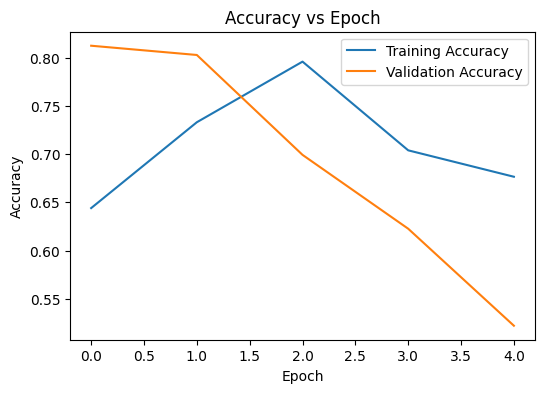

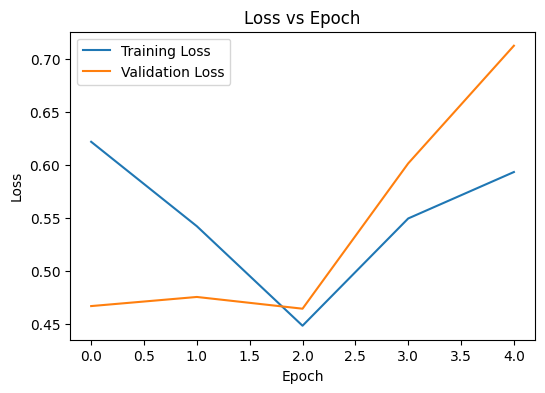

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.5093 - loss: 0.7183

Test Loss: 0.7182743549346924
Test Accuracy: 0.5093200206756592
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step

Evaluation Metrics
Accuracy : 0.50932
Precision: 0.5122463996636182
Recall   : 0.38984
F1-Score : 0.44273838186526143

Confusion Matrix:
[[7860 4640]
 [7627 4873]]


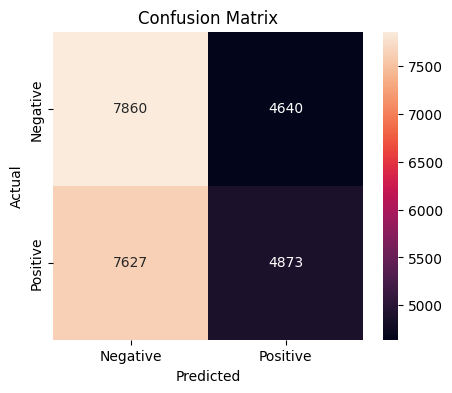

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Sample Predictions:

Review: This movie was amazing and I really loved it
Predicted Sentiment: Negative

Review: The movie was boring and disappointing
Predicted Sentiment: Negative


In [4]:
print("Ramya R")
print("24BAD096")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix
import seaborn as sns

# Train the model
history = model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=128
)

# Record accuracy and loss
print("\nTraining Accuracy:",
      history.history['accuracy'][-1])

print("Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Training Loss:",
      history.history['loss'][-1])

print("Validation Loss:",
      history.history['val_loss'][-1])

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# Evaluate using test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predict test data
y_prob = model.predict(x_test)
y_pred = (y_prob >= 0.5).astype(int).flatten()

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Sample sentiment predictions
sample_reviews = [
    "This movie was amazing and I really loved it",
    "The movie was boring and disappointing"
]

# Convert sample reviews into sequences
word_index = imdb.get_word_index()

def encode_review(review):
    words = review.lower().split()
    sequence = []

    for word in words:
        if word in word_index:
            index = word_index[word] + 3
            if index < vocab_size:
                sequence.append(index)
        else:
            sequence.append(2)

    return sequence

sample_sequences = [encode_review(review) for review in sample_reviews]

sample_padded = pad_sequences(
    sample_sequences,
    maxlen=max_length,
    padding='post'
)

# Predict sample reviews
sample_predictions = model.predict(sample_padded)

print("\nSample Predictions:")

for i in range(len(sample_reviews)):
    if sample_predictions[i][0] >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("\nReview:", sample_reviews[i])
    print("Predicted Sentiment:", sentiment)